<a href="https://colab.research.google.com/github/euleralencar/projeto_ciencia_dados_ibmec/blob/main/01_tabular_data_exploration_ex_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Exercício M1.01

Imagine que estamos interessados em prever a espécie de pinguins com base em
duas medidas do corpo deles: o comprimento do cúlmen (culmen length) e a
profundidade do cúlmen (culmen depth) — o cúlmen é a parte superior do bico.
Primeiro, queremos fazer alguma exploração dos dados para nos familiarizarmos
com eles.

Quais são as features? Qual é o alvo?

Os dados estão em `../datasets/penguins_classification.csv`; carregue-os com o
`pandas` em um `DataFrame`.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jaothan26/penguins-classification-csv")

print("Path to dataset files:", path)

100%|██████████| 1.54k/1.54k [00:00<00:00, 1.83MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jaothan26/penguins-classification-csv/versions/1


In [ ]:
import pandas as pd
import os

# Assuming 'adult.csv' is the main data file within the downloaded directory
penguins = pd.read_csv(os.path.join(path, "penguins_classification.csv"))

Mostre algumas amostras dos dados.

Quantas features são numéricas? Quantas features são categóricas?

In [ ]:
# Escreva seu código aqui.
penguins.head()

,Culmen Length (mm),Culmen Depth (mm),Species,Species
0,39.1,18.7,Adelie,Adelie
1,39.5,17.4,Adelie,Adelie
2,40.3,18.0,Adelie,Adelie
3,36.7,19.3,Adelie,Adelie
4,39.3,20.6,Adelie,Adelie


Quais são as diferentes espécies de pinguins disponíveis no conjunto de dados
e quantas amostras há de cada espécie? Dica: selecione a coluna certa e use o
método
[`value_counts`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html).

In [ ]:
# Escreva seu código aqui.
bicho = "Species"
# Seleciona a primeira ocorrência da coluna 'Species' para garantir que seja uma Series.
penguins.iloc[:, penguins.columns.get_loc(bicho)].value_counts()

ValueError: Grouper for 'Species' not 1-dimensional

Plote histogramas para as features numéricas

In [ ]:
# Escreva seu código aqui.
numerical_columns = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",

]
categorical_columns = [
    "Species",

]
all_columns = numerical_columns + categorical_columns + [bicho]

penguins = penguins[all_columns]

In [ ]:
print(
    f"O conjunto de dados contém {penguins.shape[0]} amostras e "
    f"{penguins.shape[1]} colunas"
)

O conjunto de dados contém 342 amostras e 4 colunas


array([[<Axes: title={'center': 'Culmen Length (mm)'}>,
        <Axes: title={'center': 'Culmen Depth (mm)'}>]], dtype=object)

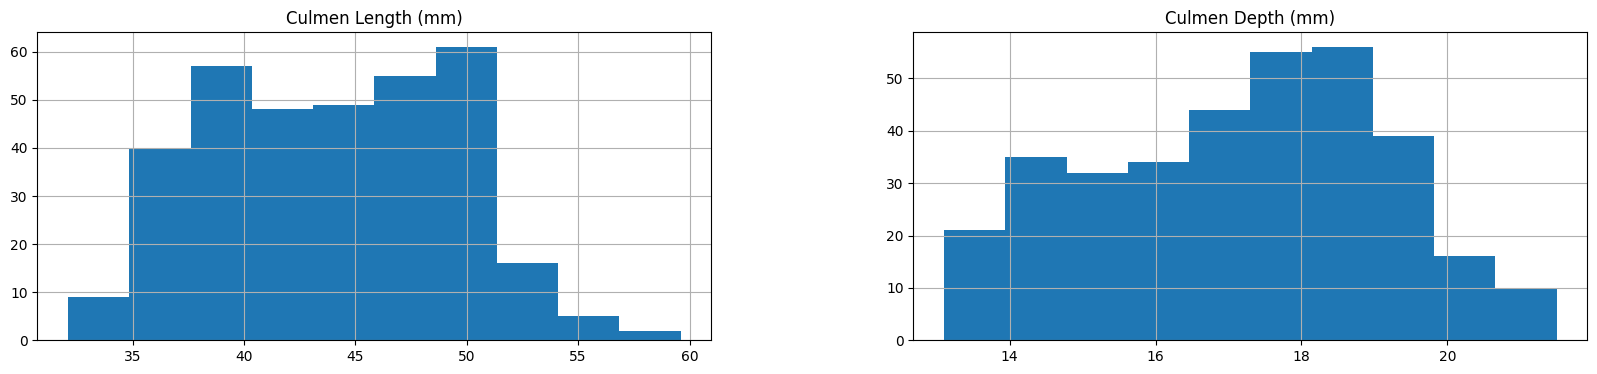

In [ ]:
penguins.hist(figsize=(20, 4))

Mostre a distribuição das features para cada classe. Dica: use
[`seaborn.pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html)

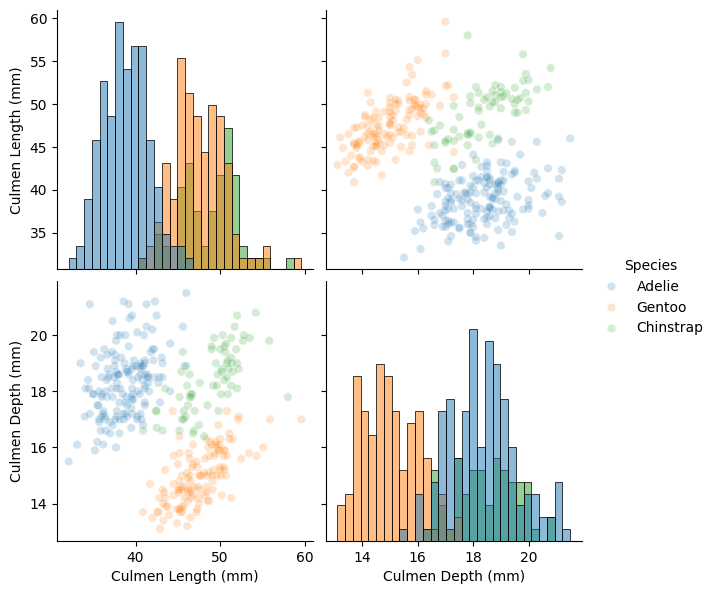

In [ ]:
import seaborn as sns

n_samples_to_plot = 5000
columns = ["Culmen Length (mm)", "Culmen Depth (mm)"]

penguins_unique_cols = penguins.loc[:, ~penguins.columns.duplicated()]

_ = sns.pairplot(
    data=penguins_unique_cols[:n_samples_to_plot],
    vars=columns,
    hue=bicho,
    plot_kws={"alpha": 0.2},
    height=3,
    diag_kind="hist",
    diag_kws={"bins": 30},
)

Olhando para essas distribuições, quão difícil você acha que seria classificar
os pinguins usando apenas `"culmen depth"` e `"culmen length"`?